## Проект: Исследование стартапов
Автор: Сорокина Мария
Дата: 17.10.25

<div class="alert alert-info">
<h2>Введение</h2>
В рамках проекта вам предстоит:
<ol>
<li>Провести предобработку данных, убрать дубликаты и пропуски, проверить корректность числовых и временных значений.</li>
<li>Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.</li>
<li>Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе.</li>
<li>Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.</li>
<li>Сравнить популярность и объёмы разных типов финансирования.</li>
<li>Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.</li>
<li>Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.</li>
<li>Подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год.</li>
    </ol>
<h3>Описание таблиц</h3>
<h4>Таблица cb_investments</h4>
<p>Содержит информацию о компаниях и состоявшемся финансировании:</p>
<ul>
    <li>name — название компании;</li>
    <li>homepage_url — ссылка на сайт компании;</li>
    <li>category_list — категории, в которых работает компания. Указываются через |;</li>
    <li>market — основной рынок или отрасль компании;</li>
    <li>funding_total_usd — общий объём привлечённых инвестиций в долларах США;</li>
    <li>status — текущий статус компании, например, operating, closed и так далее;</li>
    <li>country_code — код страны, например USA;</li>
    <li>state_code — код штата или региона, например CA;</li>
    <li>region — регион, например SF Bay Area;</li>
    <li>city — город, в котором расположена компания;</li>
    <li>funding_rounds — общее число раундов финансирования;</li>
    <li>participants — число участников в раундах финансирования;</li>
    <li>founded_at — дата основания компании;</li>
    <li>founded_month — месяц основания в формате YYYY-MM;</li>
    <li>founded_quarter — квартал основания в формате YYYY-QN;</li>
    <li>founded_year — год основания;</li>
    <li>first_funding_at — дата первого финансирования;</li>
    <li>mid_funding_at — дата среднего по времени раунда финансирования;</li>
    <li>last_funding_at — дата последнего финансирования;</li>
    <li>seed — сумма инвестиций на посевной стадии;</li>
    <li>venture — сумма венчурных инвестиций;</li>
    <li>equity_crowdfunding — сумма, привлечённая через долевой краудфандинг;</li>
    <li>undisclosed — сумма финансирования нераскрытого типа;</li>
    <li>convertible_note — сумма инвестиций через конвертируемые займы;</li>
    <li>debt_financing — сумма долгового финансирования;</li>
    <li>angel — сумма инвестиций от бизнес-ангелов;</li>
    <li>grant — сумма полученных грантов;</li>
    <li>private_equity — сумма инвестиций в виде прямых (частных) вложений;</li>
    <li>post_ipo_equity — сумма финансирования после IPO;</li>
    <li>post_ipo_debt — сумма долгового финансирования после IPO;</li>
    <li>secondary_market — сумма сделок на вторичном рынке;</li>
    <li>product_crowdfunding — сумма, привлечённая через продуктовый краудфандинг;</li>
    <li>round_A — round_H — сумма инвестиций в соответствующем раунде.</li>
</ul>

<h4>Таблица cb_returns</h4>
<p>Содержит информацию об объёмах возвратов по годам и типам финансирования в миллионах долларов:</p>
<ul>
    <li>year — год возврата средств;</li>
    <li>seed — сумма возвратов от посевных инвестиций;</li>
    <li>venture — сумма возвратов от венчурных инвестиций;</li>
    <li>equity_crowdfunding — сумма, возвращённая по долевому краудфандингу;</li>
    <li>undisclosed — сумма возвратов нераскрытого типа;</li>
    <li>convertible_note — сумма возвратов через конвертируемые займы;</li>
    <li>debt_financing — сумма возвратов от долгового финансирования;</li>
    <li>angel — сумма возвратов бизнес-ангелам;</li>
    <li>grant — сумма возвратов по грантам;</li>
    <li>private_equity — сумма возвратов прямых (частных) вложений;</li>
    <li>post_ipo_equity — сумма возвратов от IPO;</li>
    <li>post_ipo_debt — сумма возвратов от долгового IPO;</li>
    <li>secondary_market — сумма возвратов от сделок на вторичном рынке;</li>
    <li>product_crowdfunding — сумма возвратов по продуктовому краудфандингу.</li>
</ul>
</div>

# 1.1. Вывод общей информации, исправление названия столбцов

- Загрузите все данные по проекту.
- Проверьте названия столбцов.
- Выведите информацию, которая необходима вам для принятия решений о предобработке, для каждого из датасетов.

In [ ]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

In [3]:
try:
    cb_investments = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
except:
    cb_investments = pd.read_csv('cb_investments.csv')
try:
    cb_returns = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.zip", sep=';', low_memory=False)
except:
    cb_returns = pd.read_csv('cb_returns.csv')

# 1.2. Предобработка данных
Проверьте названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведите их к единому аккуратному стилю.

In [4]:
def check_df(dataset_name):
    print('Столбцы:')
    print(list(dataset_name.columns))
    print('-----------------------')
    print('Информация о датасете:')
    print(dataset_name.info())

Уберите в столбце funding_total_usd выделение разрядов и приведите его к числовому типу.
Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.
Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

In [5]:
cb_investments[['name', 'homepage_url', 'category_list', ' market ', ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region', 'city']].head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland


In [6]:
cb_investments[['funding_rounds', 'participants', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'seed']].head()

,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed
0,1.0,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06,0.0
1,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15,0.0
2,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0
3,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0
4,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14,0.0


In [7]:
cb_investments[['venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']].head()

,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
check_df(cb_investments)

Столбцы:
['name', 'homepage_url', 'category_list', ' market ', ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']
-----------------------
Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-nul

<div class="alert alert-info">
    Столбцы market и funding_total_usd имеют пробелы в начале и конце своих названий. Их необходимо удалить из названия столбцов:
</div>

In [9]:
cb_investments.columns = cb_investments.columns.str.strip()

In [10]:
cb_investments['market'] = cb_investments['market'].str.strip()

<div class="alert alert-info">
    Столбец funding_total_usd должен иметь тип данных float по своему смыслу(общий объём привлечённых инвестиций в долларах США), но перед изменением типа нужно убрать запятые.</div>

In [11]:
cb_investments['funding_total_usd'] = cb_investments['funding_total_usd'].str.replace(',', '').str.strip().replace('-', '0').str.replace('','0')
cb_investments['funding_total_usd'] = cb_investments['funding_total_usd'].astype(float)

In [12]:
for i in cb_investments.columns:
    if cb_investments[i].dtype == 'object':
        cb_investments[i] = cb_investments[i].fillna('не указано').replace('', 'не указано').replace('-', 'не указано')  

Обработайте полные дубликаты в данных и пропуски в funding_total_usd. <br>
Избавьтесь от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании. 

In [13]:
cb_investments.drop_duplicates(inplace=True)
cb_investments = cb_investments[cb_investments['funding_total_usd'].notna() & (cb_investments['funding_total_usd'] != '')]

In [14]:
cb_investments = cb_investments[cb_investments['founded_year'].notna() & (cb_investments['founded_year'] != '')]
cb_investments = cb_investments[cb_investments['participants'].notna() & (cb_investments['participants'] != '')]

Заполните пропуски в значениях mid_funding_at на основании значений в столбцах first_funding_at и last_funding_at. В качестве нового значения вместо пропусков возьмите приблизительно середину интервала между этими двумя датами.

In [15]:
# Преобразуем столбцы в формат datetime
cb_investments['first_funding_at'] = pd.to_datetime(cb_investments['first_funding_at'], errors='coerce')
cb_investments['last_funding_at'] = pd.to_datetime(cb_investments['last_funding_at'], errors='coerce')
# Заполняем пропуски в mid_funding_at
cb_investments['mid_funding_at'] = cb_investments.apply(lambda row: 
    row['first_funding_at'] + (row['last_funding_at'] - row['first_funding_at']) / 2 
    if pd.isna(row['mid_funding_at']) and pd.notna(row['first_funding_at']) and pd.notna(row['last_funding_at']) else row['mid_funding_at'], 
    axis=1)

В датасете cb_returns сделайте столбец year индексом всего датасета, если не делали это при загрузке.<br>
Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.<br>
Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

In [16]:
cb_returns

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
1,2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2,2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
3,2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
4,2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
5,2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
6,2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
7,2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
8,2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00
9,2009,160.21,2501.29,0.18,37.50,2.25,394.10,97.21,0.0,203.70,76.76,0.00,0.12,0.02


In [17]:
for column in cb_returns.columns:
    if column != 'year':
        cb_returns[column] = cb_returns[column].apply(lambda x: x * 1_000_000) 

In [18]:
cb_returns

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16700000.0,5.540000e+07,0.0,78210000.0,0.0,8.660000e+06,6430000.0,0.0,0.0,940000.0,0.0,200000.0,0.0
1,2001,2880000.0,2.349000e+07,0.0,21500000.0,10000.0,4.490000e+06,1180000.0,0.0,0.0,460000.0,0.0,460000.0,0.0
2,2002,6590000.0,2.094200e+08,0.0,25770000.0,20000.0,3.420000e+06,3410000.0,0.0,1510000.0,340000.0,0.0,60000.0,0.0
3,2003,7740000.0,2.338600e+08,0.0,9400000.0,10000.0,1.090000e+06,3410000.0,0.0,1620000.0,2110000.0,0.0,80000.0,0.0
4,2004,9930000.0,5.559000e+08,0.0,33190000.0,10000.0,1.355000e+07,9180000.0,0.0,2190000.0,3380000.0,0.0,550000.0,0.0
5,2005,26600000.0,2.628920e+09,0.0,9510000.0,20000.0,3.509000e+07,31060000.0,0.0,2400000.0,3510000.0,0.0,50000.0,0.0
6,2006,61810000.0,3.100180e+09,190000.0,46740000.0,1780000.0,1.132100e+08,47750000.0,0.0,16670000.0,20580000.0,0.0,120000.0,0.0
7,2007,70410000.0,3.585370e+09,10000.0,55370000.0,3220000.0,1.256800e+08,164510000.0,0.0,88810000.0,24360000.0,0.0,570000.0,0.0
8,2008,89720000.0,2.717020e+09,30000.0,41020000.0,1710000.0,3.975400e+08,102830000.0,0.0,130380000.0,84280000.0,0.0,470000.0,0.0
9,2009,160210000.0,2.501290e+09,180000.0,37500000.0,2250000.0,3.941000e+08,97210000.0,0.0,203700000.0,76760000.0,0.0,120000.0,20000.0


In [19]:
check_df(cb_returns)

Столбцы:
['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']
-----------------------
Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post

<div class="alert alert-info">
    Столбцы все в одном формате. Типы данных также не требуют изменений.Пропусков не обнаружено.</div>

In [20]:
cb_returns = cb_returns.set_index('year')

Оцените размер оставшихся пропусков в столбце.

In [21]:
def nan_fraction(df):
    missing_count = df.isna().sum()
    total_rows = df.shape[0]
    missing_proportion = missing_count / total_rows
    print(missing_proportion)

In [22]:
nan_fraction(cb_investments)

name                    0.000000
homepage_url            0.000000
category_list           0.000000
market                  0.000000
funding_total_usd       0.000000
status                  0.000000
country_code            0.000000
state_code              0.000000
region                  0.000000
city                    0.000000
funding_rounds          0.000000
participants            0.000000
founded_at              0.000000
founded_month           0.000000
founded_quarter         0.000000
founded_year            0.000000
first_funding_at        0.000081
mid_funding_at          0.000000
last_funding_at         0.000000
seed                    0.000000
venture                 0.000000
equity_crowdfunding     0.000000
undisclosed             0.000000
convertible_note        0.000000
debt_financing          0.000000
angel                   0.000000
grant                   0.000000
private_equity          0.000000
post_ipo_equity         0.000000
post_ipo_debt           0.000000
secondary_

<div class="alert alert-info">Пропусков крайне мало.</div>.
</div>

In [23]:
nan_fraction(cb_returns)

seed                    0.0
venture                 0.0
equity_crowdfunding     0.0
undisclosed             0.0
convertible_note        0.0
debt_financing          0.0
angel                   0.0
grant                   0.0
private_equity          0.0
post_ipo_equity         0.0
post_ipo_debt           0.0
secondary_market        0.0
product_crowdfunding    0.0
dtype: float64


<div class="alert alert-info">
Пропусков нет</div>

Оцените полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?

<div class="alert alert-info">Данные потерпели незначительные изменения и их должно быть достаточно для анализа.</div>

In [24]:
cb_investments = cb_investments.drop(['category_list', 'homepage_url','status', 'country_code', 'state_code', 'region', 'city','participants','founded_at', 'founded_month', 'founded_quarter', 'founded_year'], axis=1)

In [25]:
cb_investments.columns

Index(['name', 'market', 'funding_total_usd', 'funding_rounds',
       'first_funding_at', 'mid_funding_at', 'last_funding_at', 'seed',
       'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
       'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
       'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A',
       'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G',
       'round_H'],
      dtype='object')

In [26]:
# Шаг 1: Проверяем наличие числовых столбцов с значениями 0 или NaN
numeric_columns = ['funding_total_usd']
has_zeros_or_nans = cb_investments[numeric_columns].isin([0, np.nan]).any().any()

# Шаг 2: Фильтруем строки, содержащие 0 или NaN в числовых столбцах
filtered_rows = cb_investments[cb_investments[numeric_columns].isin([0, np.nan]).any(axis=1)]

# Шаг 3: Сравниваем количество отфильтрованных строк с изначальным датасетом в процентном соотношении
initial_rows_count = len(cb_investments)
filtered_rows_count = len(filtered_rows)
percentage_filtered = (filtered_rows_count / initial_rows_count) * 100

print(f"Процент отфильтрованных строк: {percentage_filtered:.2f}%")

Процент отфильтрованных строк: 9.26%


In [27]:
cb_investments = cb_investments[~cb_investments[numeric_columns].isin([0, np.nan]).any(axis=1)]

# Шаг 2. Инжиниринг признаков
При выполнении заданий не забывайте интерпретировать полученные результаты и делать промежуточные выводы.
## 2.1. Группы по срокам финансирования
Разделите все компании на три группы:
* Единичное финансирование — был всего один раунд финансирования.
* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.
* Срок финансирования более года.
  
Визуализируйте соотношение этих групп, создав два графика:
* По количеству компаний: покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

<div class="alert alert-info">
    По визуализациям можно сделать промежуточный вывод: 
    В датасете больше групп со сроком финансирования до года, но большая часть средств привлечена от компаний, срок финансирования которых более года.
</div>

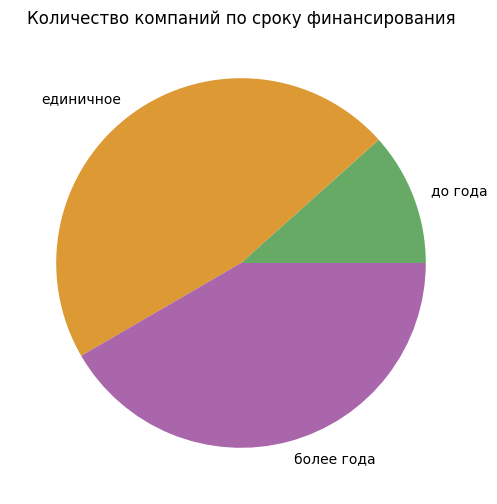

In [29]:
mask_once = cb_investments['funding_rounds'] == 1
mask_year = (cb_investments['last_funding_at'] - cb_investments['first_funding_at']).dt.days <= 366

long, short, once = 'более года', 'до года', 'единичное'

cb_investments['funding_type'] = long
cb_investments.loc[mask_year, 'funding_type'] = short
cb_investments.loc[mask_once, 'funding_type'] = once

category_colors = {
    short: "#66AA66",
    once: "#DD9933",
    long: "#AA66AA"
}

cb_investments.funding_type.value_counts(dropna=False)[category_colors.keys()]\
    .plot(
        kind='pie',
        figsize=(8, 6),
        title='Количество компаний по сроку финансирования',
        ylabel='',
        colors=category_colors.values(),
        );

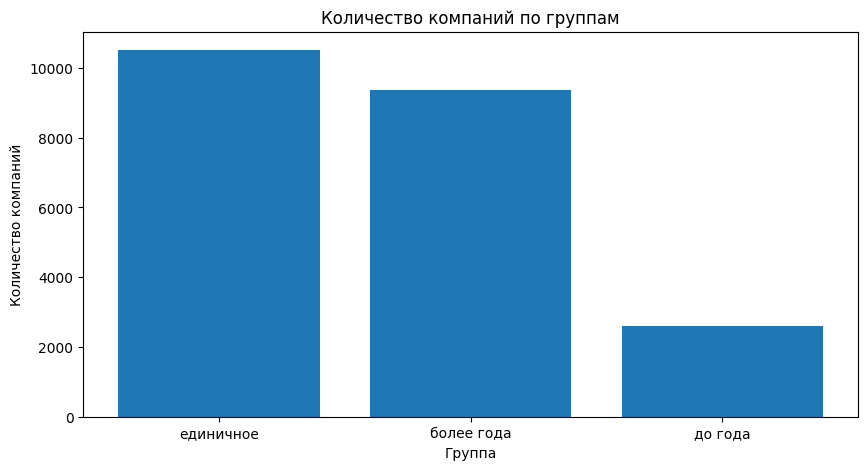

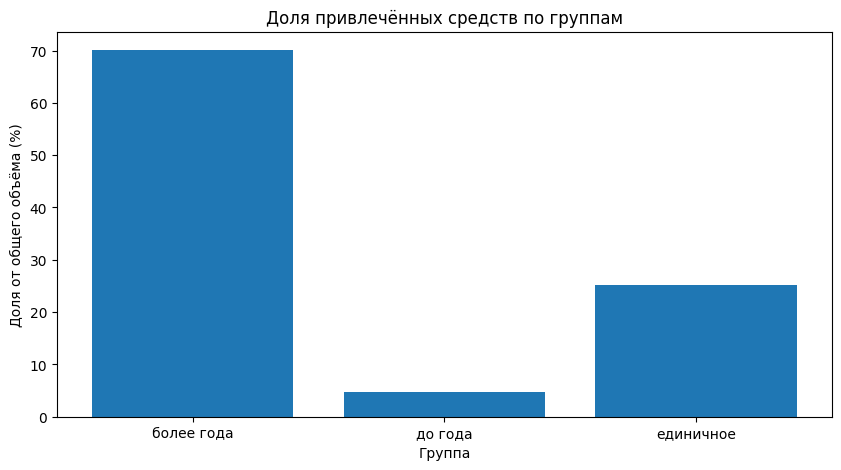

In [30]:
# Подсчитываем количество компаний в каждой группе
group_counts = cb_investments['funding_type'].value_counts()

# Рассчитываем долю от общего объёма инвестиций для каждой группы
total_investments = cb_investments['funding_total_usd'].sum()
group_investments = cb_investments.groupby('funding_type')['funding_total_usd'].sum() / total_investments * 100

# График по количеству компаний
plt.figure(figsize=(10, 5))
plt.bar(group_counts.index, group_counts.values)
plt.title('Количество компаний по группам')
plt.xlabel('Группа')
plt.ylabel('Количество компаний')
plt.show()

# График по объёму инвестиций
plt.figure(figsize=(10, 5))
plt.bar(group_investments.index, group_investments.values)
plt.title('Доля привлечённых средств по группам')
plt.xlabel('Группа')
plt.ylabel('Доля от общего объёма (%)')
plt.show()

# 2.2 Выделение средних и нишевых сегментов рынка
Компании указывают свой сегмент рынка в столбце market. Рассчитайте, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. <br>
Рассчитайте, сколько сегментов попадает в каждую из категорий.
Постройте график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.<br.
Оставьте в столбце market только массовые сегменты. Для остальных сегментов замените значения на заглушки — niche для нишевых и mid для средних.<br/>
Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.

In [31]:
# Подсчитываем количество компаний в каждом сегменте
segment_counts = cb_investments['market'].value_counts()
segment_counts

market
Software                      3026
Biotechnology                 1919
Mobile                        1490
Curated Web                   1177
E-Commerce                    1043
                              ... 
Service Industries               1
Educational Games                1
Specialty Foods                  1
iPad                             1
Medical Marijuana Patients       1
Name: count, Length: 179, dtype: int64

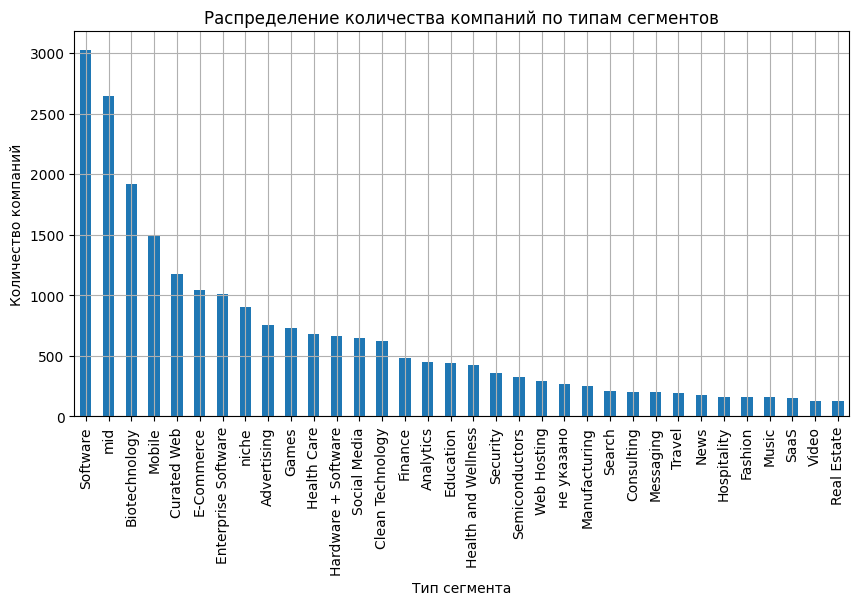

In [32]:
segment_counts = cb_investments['market'].value_counts()

# Определяем категории сегментов
massive_segments = segment_counts[segment_counts > 120].index
mid_segments = segment_counts[(segment_counts >= 35) & (segment_counts <= 120)].index
niche_segments = segment_counts[segment_counts < 35].index

# Заменяем значения в столбце market на заглушки для нишевых и средних сегментов,
# сохраняя названия массовых сегментов
cb_investments['market'] = cb_investments['market'].apply(
    lambda x: x if x in massive_segments else ('mid' if x in mid_segments else 'niche')
)

# Группируем данные по новым категориям сегментов
grouped_segments = cb_investments['market'].value_counts()
# Построим график распределения количества компаний по трем типам сегментов
plt.figure(figsize=(10, 5))
grouped_segments.plot(kind='bar')
plt.title('Распределение количества компаний по типам сегментов')
plt.xlabel('Тип сегмента')
plt.ylabel('Количество компаний')
plt.grid()
plt.show()

In [33]:
cb_investments['market'].value_counts()

market
Software               3026
mid                    2646
Biotechnology          1919
Mobile                 1490
Curated Web            1177
E-Commerce             1043
Enterprise Software    1009
niche                   900
Advertising             758
Games                   729
Health Care             684
Hardware + Software     665
Social Media            645
Clean Technology        623
Finance                 485
Analytics               451
Education               439
Health and Wellness     421
Security                362
Semiconductors          329
Web Hosting             290
не указано              270
Manufacturing           253
Search                  210
Consulting              201
Messaging               201
Travel                  191
News                    174
Hospitality             163
Fashion                 160
Music                   157
SaaS                    154
Video                   130
Real Estate             128
Name: count, dtype: int64

## Шаг 3. Работа с выбросами и анализ
# 3.1. Анализируем и помечаем выбросы в каждом из сегментов
Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.<br>
По предобработанному столбцу funding_total_usd графическим образом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажите интервал, в котором лежат типичные значения.<br>
Определите компании с аномальным объёмом общего финансирования — используйте метод IQR отдельно по каждому сегменту. Напомним, что все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.<br>
Определите сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведите топ таких сегментов.

In [34]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)
cb_investments['funding_total_usd'].describe()

count                  22483.00000
mean       18227516645040712.00000
std       490497419120013632.00000
min                   209010.00000
25%             506050000010.00000
50%           30000000000000.00000
75%         1030400500450005.00000
max     50700000000000000000.00000
Name: funding_total_usd, dtype: float64

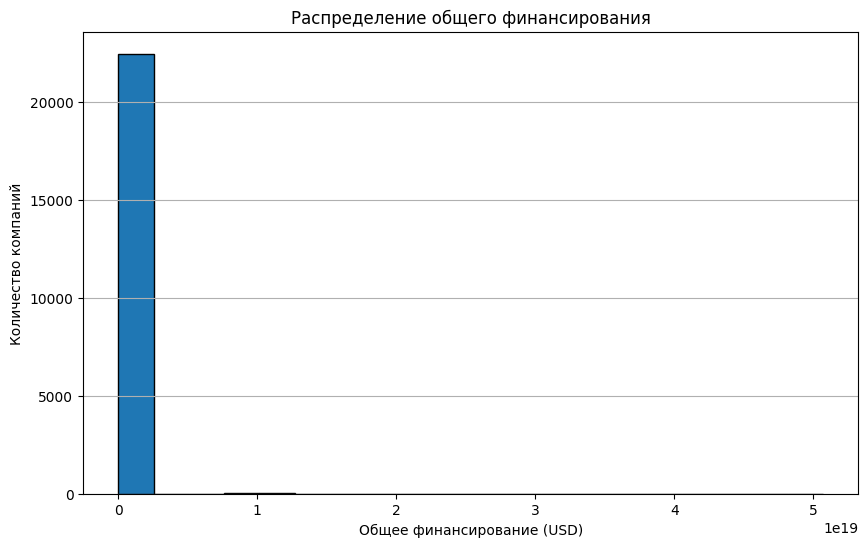

In [35]:
# Построение гистограммы
plt.figure(figsize=(10, 6))
plt.hist(cb_investments['funding_total_usd'], bins=20, edgecolor='black')
plt.title('Распределение общего финансирования')
plt.xlabel('Общее финансирование (USD)')
plt.ylabel('Количество компаний')
plt.grid(axis='y')
plt.show()

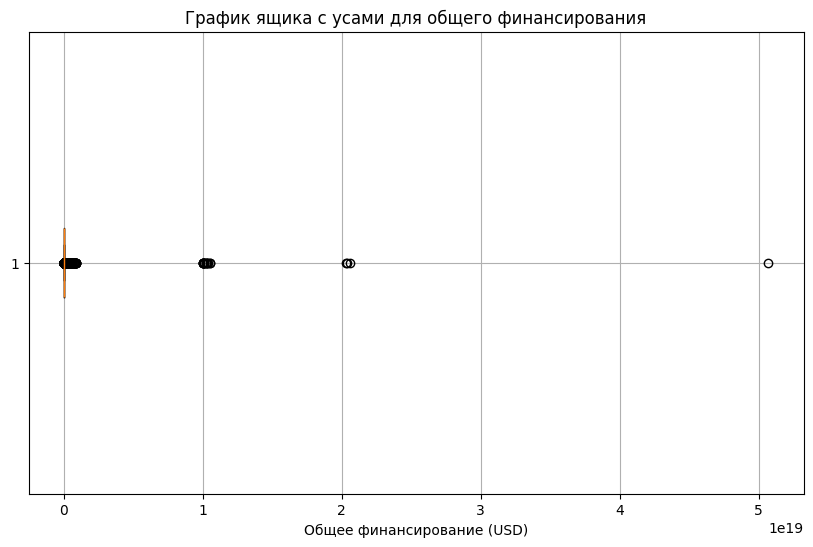

In [36]:
# Построение графика ящик с усами
plt.figure(figsize=(10, 6))
plt.boxplot(cb_investments['funding_total_usd'], vert=False, whis=1.5)
plt.title('График ящика с усами для общего финансирования')
plt.xlabel('Общее финансирование (USD)')
plt.grid()
plt.show()

<div class="alert alert-info">
    Метод describe и графики разброса показывают:<ul>
<li>Типичный размер общего финансирования для одной компании лежит в интервале между 25-м и 75-м процентилями, то есть от 506050000010.00000
30000000000000.00000. Это означает, что половина компаний имеет финансирование в этом диапазоне.</li>
<li>Выбивающиеся значения будут находиться за пределами этого интервала. Особенно стоит обратить внимание на максимальное значение в 50 700 000 000 000 000 000, которое значительно превышает остальные значения и может считаться аномально высоким.</li></ul>
Таким образом, интервал от от 506050000010.00000 до 30000000000000.00000 можно считать диапазоном типичных значений для общего финансирования компаний.
</div>

In [37]:
niche_group = cb_investments[cb_investments['market'] == 'niche']
average_group = cb_investments[cb_investments['market'] == 'mid']

# Рассчитаем IQR для каждой группы
def calculate_iqr(group):
    Q1 = group['funding_total_usd'].quantile(0.25)
    Q3 = group['funding_total_usd'].quantile(0.75)
    IQR = Q3 - Q1
    return IQR

iqr_niche = calculate_iqr(niche_group)
iqr_average = calculate_iqr(average_group)

# Определим аномальные значения для каждой группы
def identify_anomalies(group, iqr):
    Q1 = group['funding_total_usd'].quantile(0.25)
    Q3 = group['funding_total_usd'].quantile(0.75)
    lower_bound = Q1 - 1.5 * iqr
    upper_bound = Q3 + 1.5 * iqr
    return group[(group['funding_total_usd'] < lower_bound) | (group['funding_total_usd'] > upper_bound)]

anomalous_niche = identify_anomalies(niche_group, iqr_niche)
anomalous_average = identify_anomalies(average_group, iqr_average)

In [38]:
try:
    niche_anomaly_ratio = len(anomalous_niche) / len(niche_group)
    print(f"Доля аномальных компаний в нишевом сегменте: {niche_anomaly_ratio}")
except ZeroDivisionError:
    print('деление на ноль')

Доля аномальных компаний в нишевом сегменте: 0.1511111111111111


In [39]:
try:
    average_anomaly_ratio = len(anomalous_average) / len(average_group)
    print(f"Доля аномальных компаний в среднем сегменте: {average_anomaly_ratio}")
except ZeroDivisionError:
    print('деление на ноль')

Доля аномальных компаний в среднем сегменте: 0.12396069538926682


In [40]:
# Выводим топ сегментов с наибольшей долей аномальных компаний
segments = {'нишевый': niche_anomaly_ratio,'средний':average_anomaly_ratio}
top_segments = sorted(segments, key=segments.get, reverse=True)
print("Топ сегментов с наибольшей долей аномальных компаний:")
for segment in top_segments:
    print(f"{segment}: {segments[segment]}")

Топ сегментов с наибольшей долей аномальных компаний:
нишевый: 0.1511111111111111
средний: 0.12396069538926682


<div class="alert alert-info">
    Средний сегмент оказался пустым, в нишевом сегменте относительно небольшая доля аномальных выбросов.
</div>

# 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии
Проверьте по датасету, можно ли считать, что вам предоставили полные данные за 2014 год. Затем исключите из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.<br>
Когда исключите аномальные записи, на основе столбцов mid_funding_at и funding_rounds оставьте в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.<br>

In [41]:
cb_investments['mid_funding_at'] = pd.to_datetime(cb_investments['mid_funding_at'], errors='coerce')
data_2014 = cb_investments[cb_investments['mid_funding_at'].dt.year == 2014]
print("Количество записей за 2014 год:", len(data_2014))

# Анализ диапазона дат и других параметров для оценки полноты данных
print("Минимальная дата за 2014 год:", data_2014['mid_funding_at'].min())
print("Максимальная дата за 2014 год:", data_2014['mid_funding_at'].max())

# Шаг 2: Определение аномальных компаний по перцентилям funding_total_usd
# Рассчитаем перцентили
q25 = cb_investments['funding_total_usd'].quantile(0.25)
q75 = cb_investments['funding_total_usd'].quantile(0.75)

# Определим аномальные компании как те, у которых funding_total_usd выходит за границы перцентилей
anomalous_companies = cb_investments[(cb_investments['funding_total_usd'] < q25) | (cb_investments['funding_total_usd'] > q75)]['name'].unique()

# Исключим аномальные компании из датасета
cb_investments = cb_investments[~cb_investments['name'].isin(anomalous_companies)]

# Шаг 3: Отбор компаний по количеству раундов финансирования
rounds_per_year = cb_investments.groupby(cb_investments['mid_funding_at'].dt.year)['funding_rounds'].count()
years_with_50_or_more_rounds = rounds_per_year[rounds_per_year >= 50].index

filtered_data = cb_investments[cb_investments['mid_funding_at'].dt.year.isin(years_with_50_or_more_rounds)]
print("Количество записей после фильтрации:", len(filtered_data))


Количество записей за 2014 год: 0
Минимальная дата за 2014 год: NaT
Максимальная дата за 2014 год: NaT
Количество записей после фильтрации: 11074


In [42]:

cb_investments['first_funding_at'] = pd.to_datetime(cb_investments['first_funding_at'], errors='coerce')

# Фильтруем по 2014 году:

df_2014 = cb_investments[cb_investments['first_funding_at'].dt.year == 2014]

# Группируем по месяцу и считаем количество записей в каждом месяце:

monthly_counts = df_2014.groupby(df_2014['first_funding_at'].dt.month).size()

# Для удобства переименуем индекс в названия месяцев:

monthly_counts.index = monthly_counts.index.map(lambda x: pd.Timestamp(year=2014, month=x, day=1).strftime('%B'))

print(monthly_counts)

first_funding_at
January      19
February     24
March        12
April        18
May          11
June         12
July         11
August        4
September     2
October       3
November      4
dtype: int64


In [43]:

cb_investments['first_funding_at'] = pd.to_datetime(cb_investments['first_funding_at'], errors='coerce')

# Фильтруем по 2014 году:

df_2014 = cb_investments[cb_investments['first_funding_at'].dt.year == 2014]

# Группируем по месяцу и считаем количество записей в каждом месяце:

monthly_counts = df_2014.groupby(df_2014['first_funding_at'].dt.month).size()

# Для удобства переименуем индекс в названия месяцев:

monthly_counts.index = monthly_counts.index.map(lambda x: pd.Timestamp(year=2014, month=x, day=1).strftime('%B'))

print(monthly_counts)

first_funding_at
January      19
February     24
March        12
April        18
May          11
June         12
July         11
August        4
September     2
October       3
November      4
dtype: int64


In [44]:
cb_investments.shape

(11233, 29)

In [45]:

cb_investments['first_funding_at'] = pd.to_datetime(cb_investments['first_funding_at'], errors='coerce')

# Фильтруем по 2014 году:

df_2014 = cb_investments[cb_investments['first_funding_at'].dt.year == 2014]

# Группируем по месяцу и считаем количество записей в каждом месяце:

monthly_counts = df_2014.groupby(df_2014['first_funding_at'].dt.month).size()

# Для удобства переименуем индекс в названия месяцев:

monthly_counts.index = monthly_counts.index.map(lambda x: pd.Timestamp(year=2014, month=x, day=1).strftime('%B'))

#-----------------------
# Преобразуем столбец mid_funding_at в формат datetime
cb_investments['mid_funding_at'] = pd.to_datetime(cb_investments['mid_funding_at'], errors='coerce')

# Группируем данные по годам и считаем количество раундов финансирования для каждого года
yearly_counts = cb_investments.groupby(cb_investments['mid_funding_at'].dt.year)['funding_rounds'].count()

# Фильтруем годы, в которых было 50 или более раундов финансирования
years_with_50_or_more_rounds = yearly_counts[yearly_counts >= 50].index

# Оставляем в датасете данные только о компаниях, которые получали финансирование в выбранные годы
cb_investments = cb_investments[cb_investments['mid_funding_at'].dt.year.isin(years_with_50_or_more_rounds)]

In [46]:
cb_investments.shape

(11074, 29)

# 3.3. Анализ типов финансирования по объёму и популярности
Постройте график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируйтесь на значения в столбцах seed, venture, equity_crowdfunding, undisclosed, convertible_note, debt_financing, angel, grant, private_equity, post_ipo_equity, post_ipo_debt, secondary_market и product_crowdfunding.<br>
Также постройте график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.<br>
Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.<br>
Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

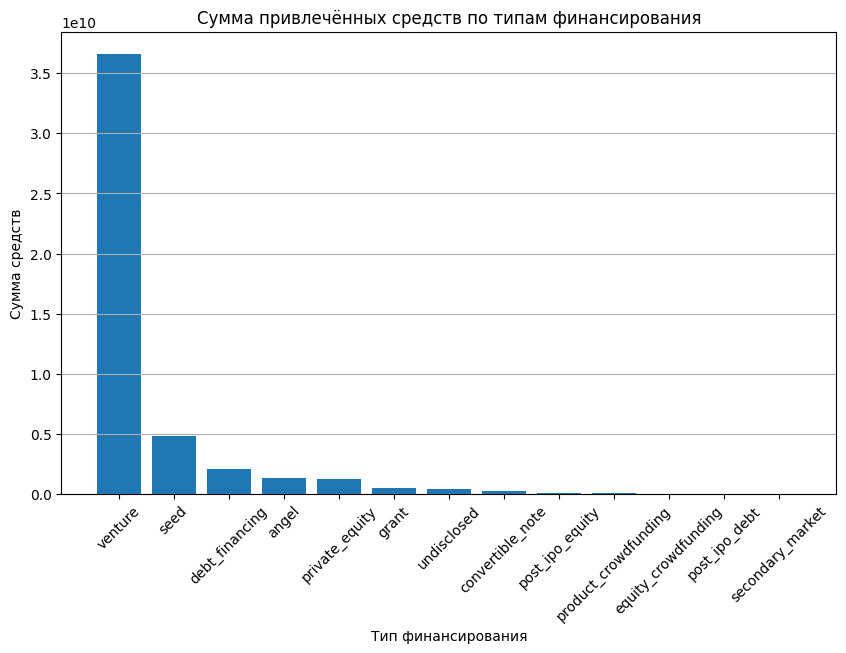

In [47]:
# Подсчитываем суммы по каждому типу финансирования

only_investments = cb_investments[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
                   'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
                   'post_ipo_debt', 'secondary_market', 'product_crowdfunding']]
total_per_type = only_investments.sum()

# Сортируем типы финансирования по сумме привлечённых средств
sorted_totals = total_per_type.sort_values(ascending=False)

# Построение графика
plt.figure(figsize=(10, 6))
plt.bar(sorted_totals.index, sorted_totals.values)
plt.title('Сумма привлечённых средств по типам финансирования')
plt.xlabel('Тип финансирования')
plt.ylabel('Сумма средств')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.show()

<div class="alert alert-info">Больше всего средств привлечено с впомощью венчурных средств.</div>

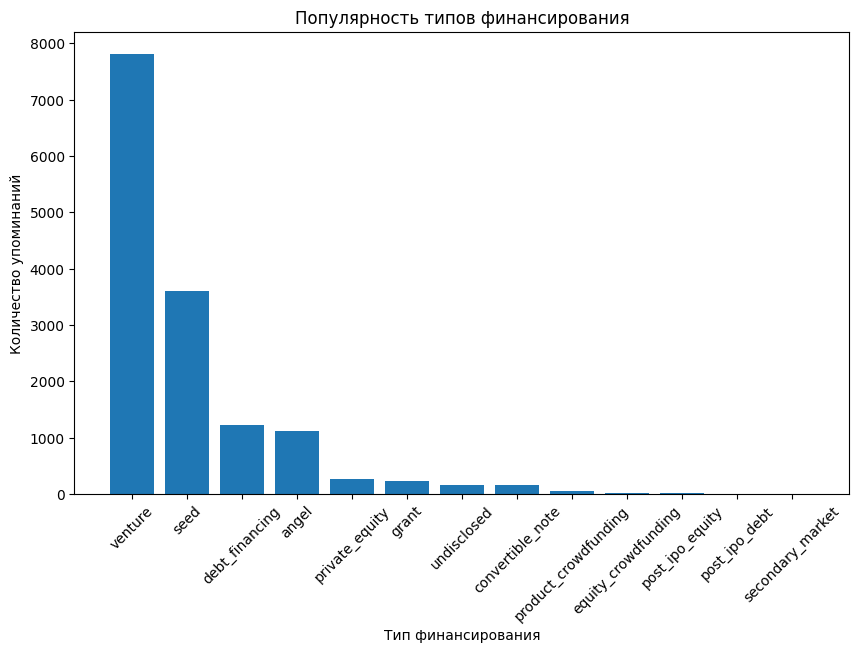

In [48]:
# Список столбцов с типами финансирования
financing_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
                   'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
                   'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

# Создаём словарь для хранения количества упоминаний каждого типа финансирования
count_dict = {column: 0 for column in financing_types}

# Проходим по каждой строке и считаем количество ненулевых значений для каждого типа
for index, row in only_investments.iterrows():
    for column in financing_types:
        if row[column] != 0.0:
            count_dict[column] += 1

# Сортируем словарь по значениям в порядке убывания
sorted_count_dict = dict(sorted(count_dict.items(), key=lambda item: item[1], reverse=True))

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(sorted_count_dict.keys(), sorted_count_dict.values())
plt.title('Популярность типов финансирования')
plt.xlabel('Тип финансирования')
plt.ylabel('Количество упоминаний')
plt.xticks(rotation=45)
plt.show()


In [49]:
sorted_count_dict

{'venture': 7816,
 'seed': 3595,
 'debt_financing': 1220,
 'angel': 1125,
 'private_equity': 256,
 'grant': 233,
 'undisclosed': 159,
 'convertible_note': 157,
 'product_crowdfunding': 42,
 'equity_crowdfunding': 20,
 'post_ipo_equity': 17,
 'post_ipo_debt': 2,
 'secondary_market': 0}

<div class="alert alert-block alert-info">
<h2> Комментарий студента v1</h2>
    По графику и таблице можно сделать вывод, что самые популярыне типы финансирования это:
<ul>
    <li>venture</li>
    <li>seed</li>
</ul>
Самый редкий тип финансирования это secondary_market -  сумма сделок на вторичном рынке
</div>

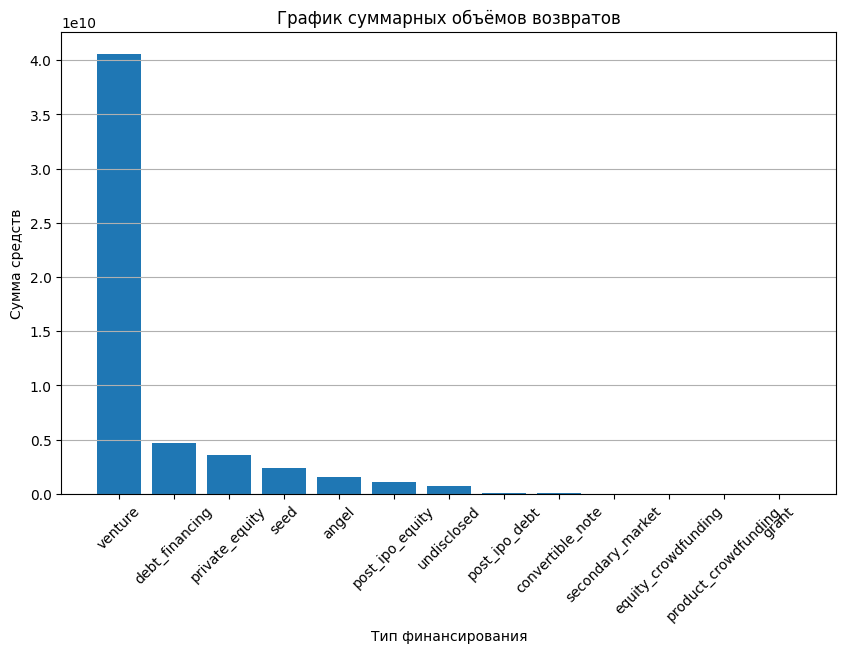

In [50]:
total_per_type = cb_returns.sum()

# Сортируем типы финансирования по сумме привлечённых средств
sorted_totals = total_per_type.sort_values(ascending=False)

# Построение графика
plt.figure(figsize=(10, 6))
plt.bar(sorted_totals.index, sorted_totals.values)
plt.title('График суммарных объёмов возвратов')
plt.xlabel('Тип финансирования')
plt.ylabel('Сумма средств')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.show()

# Шаг 4. Анализ динамики
## 4.1 Динамика предоставления финансирования по годам
Используя столбцы funding_total_usd и funding_rounds, для каждой компании рассчитайте средний объём одного раунда финансирования.
На основе получившейся таблицы постройте графики, которые отразят:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;
* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Когда будете строить графики в этом задании и следующих, используйте данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.
На основе полученных данных ответьте на вопросы:
1. В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?
2. Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

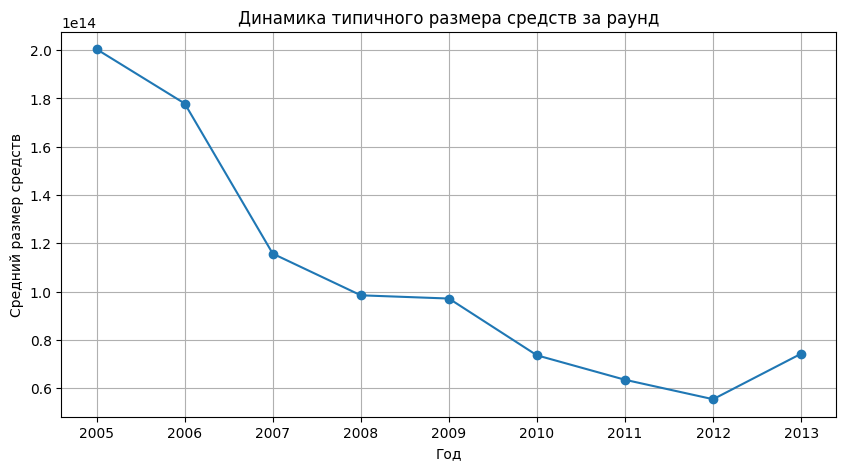

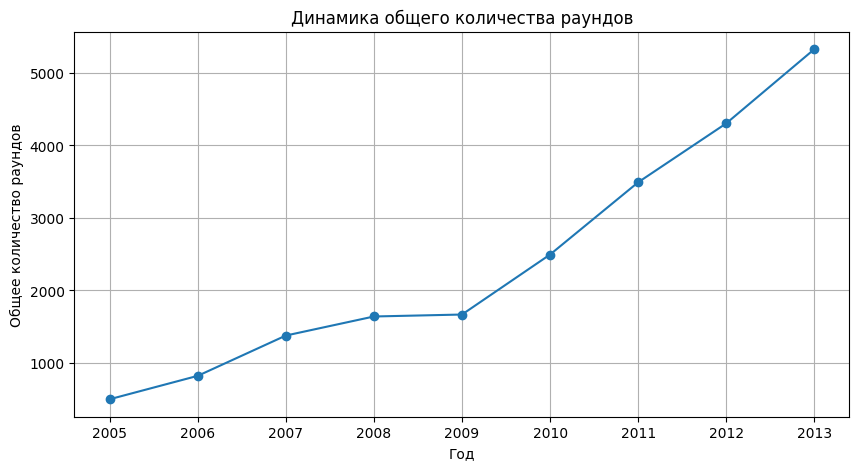

In [51]:
# Рассчитываем средний объём одного раунда для каждой компании
cb_investments['average_funding_per_round'] = cb_investments['funding_total_usd'] / cb_investments['funding_rounds']
cb_investments['year'] = pd.to_datetime(cb_investments['mid_funding_at'],errors='coerce').dt.year
# Группируем данные по годам и рассчитываем средние значения и общее количество раундов
annual_data = cb_investments.groupby('year').agg(
    average_funding=('average_funding_per_round', 'mean'),
    total_rounds=('funding_rounds', 'sum')
)

# Строим график среднего размера средств за раунд по годам
plt.figure(figsize=(10, 5))
plt.plot(annual_data.index, annual_data['average_funding'], marker='o')
plt.title('Динамика типичного размера средств за раунд')
plt.xlabel('Год')
plt.ylabel('Средний размер средств')
plt.grid()
plt.show()

# Строим график общего количества раундов по годам
plt.figure(figsize=(10, 5))
plt.plot(annual_data.index, annual_data['total_rounds'], marker='o')
plt.title('Динамика общего количества раундов')
plt.xlabel('Год')
plt.ylabel('Общее количество раундов')
plt.grid()
plt.show()

In [52]:
print(f'Максимальный средний средств за раунд финансирования был в {int(annual_data['average_funding'].idxmax())} и составил {annual_data['average_funding'].max()} USD')

Максимальный средний средств за раунд финансирования был в 2005 и составил 200399839020886.94 USD


# 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов
Составьте сводную таблицу, в которой указывается суммарный размер общего финансирования funding_total_usd по годам и сегментам рынка. Отберите из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.
На графике отразите, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматривайте только массовые сегменты, а средние и нишевые исключите.
На основе графика сделайте вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [53]:
# Группируем данные по годам и сегментам рынка и суммируем funding_total_usd
filtered_investments = cb_investments[(cb_investments['market'] != 'niche' ) & (cb_investments['market'] != 'mid')]
pivot_table = filtered_investments.groupby(['year', 'market'])['funding_total_usd'].sum().unstack()
pivot_table.index = pivot_table.index.astype(int)
# Выберем сегменты, которые показали рост в 2014 году по сравнению с 2013
growth_segments = pivot_table.loc[2013] > pivot_table.loc[2012]
selected_segments = pivot_table.columns[growth_segments].tolist()

# Создадим новую сводную таблицу только с отобранными сегментами
filtered_pivot_table = pivot_table[selected_segments]

# Теперь выводим сводную таблицу
filtered_pivot_table

market,Advertising,Analytics,Biotechnology,Clean Technology,Consulting,E-Commerce,Education,Fashion,Finance,Games,...,Health and Wellness,Hospitality,Mobile,Music,Search,Semiconductors,Software,Travel,Web Hosting,не указано
year,,,,,,,,,,,,,,,,,,,,,
2005,3111909060002020.00000,2321506131004040.00000,3678037010204000.00000,NaN,1273511020000000.00000,80500000000000.00000,40705000000000.00000,NaN,3081808050000010.00000,3421520070902010.00000,...,81711000000000.00000,702000408000.00000,5635122221807000.00000,71103000000000.00000,110800000000000.00000,5433122030900000.00000,24362419835131340.00000,1120803000000000.00000,7763802030605010.00000,1201909000000000.00000
2006,1743924161303030.00000,3383107000000000.00000,5698550200410080.00000,NaN,62214000000000.00000,1282435231605030.00000,1040000000000000.00000,NaN,1211108070200000.00000,6505831231113080.00000,...,10000000000000.00000,130902080800080.00000,5718249241506040.00000,1212700010808050.00000,192515150000000.00000,12667336312724150.00000,35938582444154208.00000,110700000000000.00000,3908129220907020.00000,2433717251111110.00000
2007,9279857272822190.00000,2082112090000000.00000,5091667615544410.00000,323513061410120.00000,2374629111303150.00000,485520270407060.00000,1163527130000010.00000,NaN,2644346111812080.00000,11394863132722150.00000,...,2211000000000000.00000,20505000000000.00000,10525017536054510.00000,283710020401040.00000,385432111408060.00000,3472830080700000.00000,32043526840620968.00000,81905000000000.00000,2353620091716100.00000,1120714000000000.00000
2008,12099249434415120.00000,1365045202114170.00000,3697665666351420.00000,11747894574969270.00000,1000004000000000.00000,4707674525152270.00000,1456337121607040.00000,1101507010808030.00000,3645842181114110.00000,5505367272916270.00000,...,81817170700000.00000,20006080109050.00000,8459513645454270.00000,392811060007000.00000,2297831151209070.00000,7894535180110120.00000,27334634833734980.00000,1283025241513010.00000,2172322040100000.00000,231209010909010.00000
2009,7375608787872320.00000,3237037230804010.00000,7542230877065480.00000,5709553484333350.00000,1202014000906000.00000,3719559722631170.00000,3304130253004130.00000,91109050205000.00000,2233121060804120.00000,5049770392522090.00000,...,424338271215090.00000,2010300000000000.00000,9341880004257400.00000,223717152012180.00000,161928212322160.00000,3424136251222160.00000,24118149452561512.00000,122313110406080.00000,2502230292720150.00000,30703070404060.00000
2010,11446091877963600.00000,4763306686958290.00000,15972111681297760.00000,4287302733142340.00000,1425622352615150.00000,7421566058870610.00000,4468652262121150.00000,161405000000000.00000,1120067462315250.00000,7298193743864730.00000,...,2526732452932240.00000,223426190712080.00000,7069876129306670.00000,193627180411050.00000,214326130908070.00000,1493937241817250.00000,22865197968965400.00000,1162519120605000.00000,2287259312133160.00000,1323240343826290.00000
2011,6170873363428010.00000,9024576683347340.00000,27995958682212660.00000,11121076755440260.00000,110612080403090.00000,7970443037857660.00000,6528444222014390.00000,1373951393727110.00000,8105108034347550.00000,5155704986260480.00000,...,6189305551211810.00000,404639372616180.00000,12230679808173420.00000,345926152626170.00000,395442300505010.00000,1362415131506160.00000,32903460439989800.00000,1246144312120180.00000,1315048202415120.00000,4525803969069670.00000
2012,5953148372191830.00000,5579807556542340.00000,22594029136420860.00000,4032160807371510.00000,1394848282219200.00000,10786689954935080.00000,5252339674839260.00000,3537744151310070.00000,5341142225356280.00000,2331603916152340.00000,...,4063007784554580.00000,285944372931160.00000,19980485040663208.00000,133325192120010.00000,1154624263315050.00000,2202719272320110.00000,28196997933088540.00000,1313814121009060.00000,365264442527170.00000,1487365542631310.00000
2013,6609489320275670.00000,7068806548982820.00000,45249149158026304.00000,14692553130407880.00000,4355657294618310.00000,178

На графике отразите, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. 


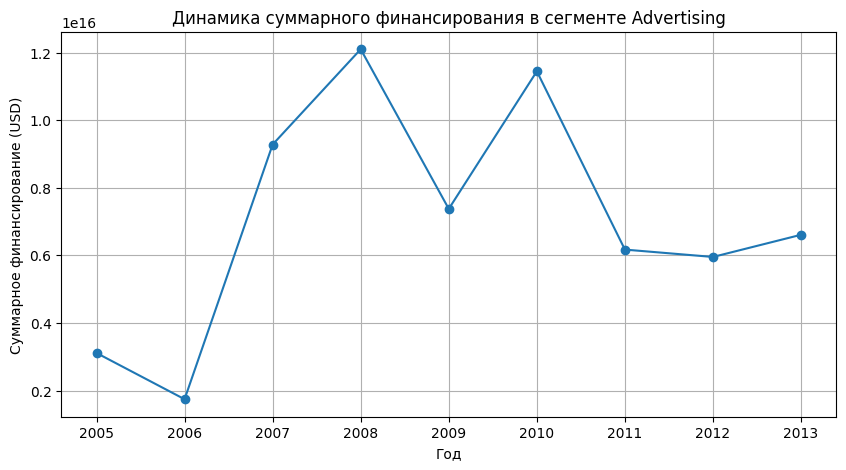

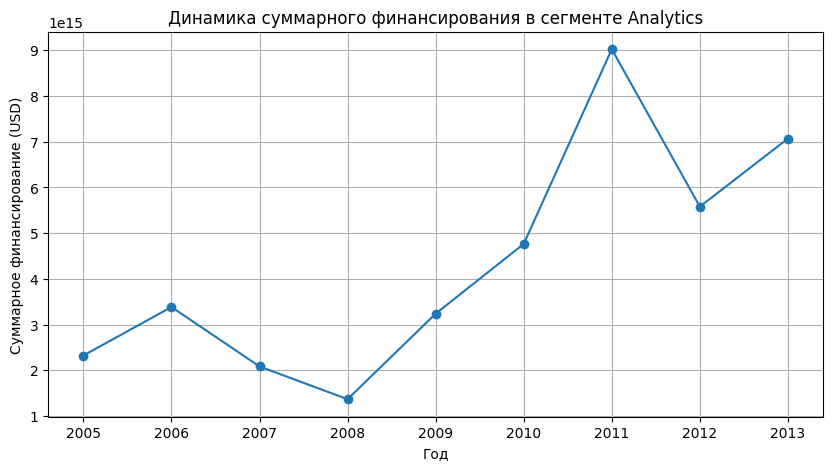

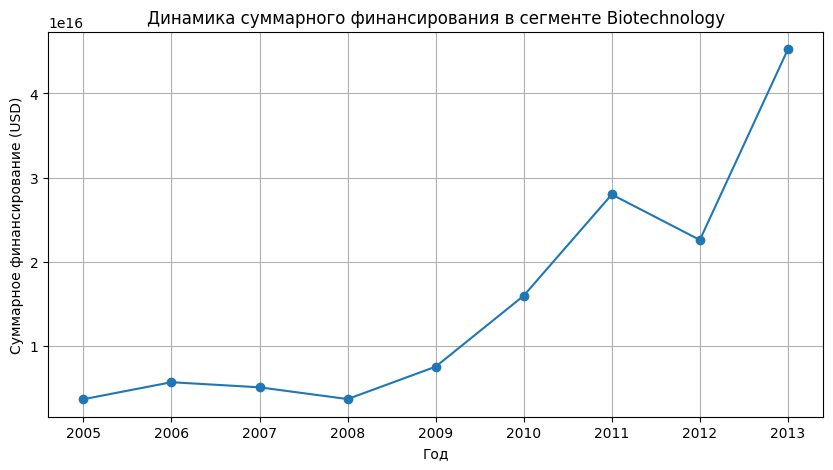

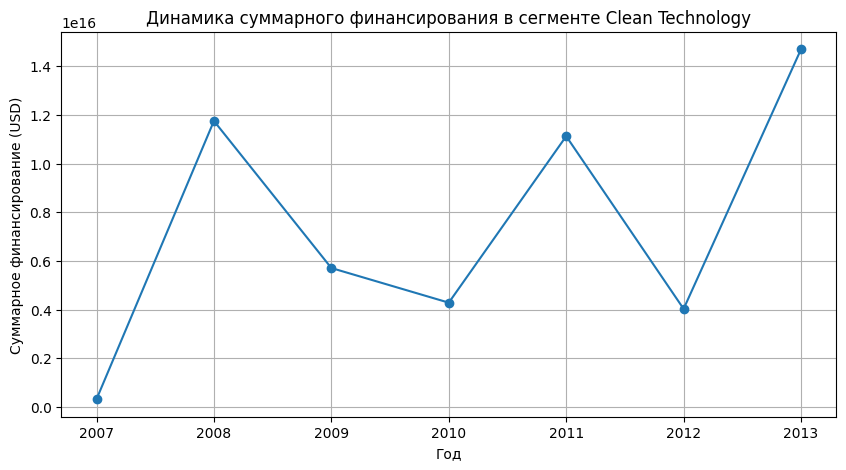

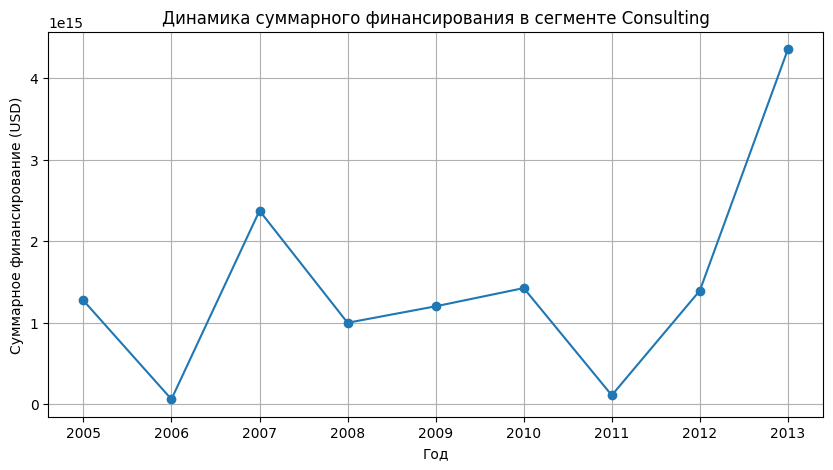

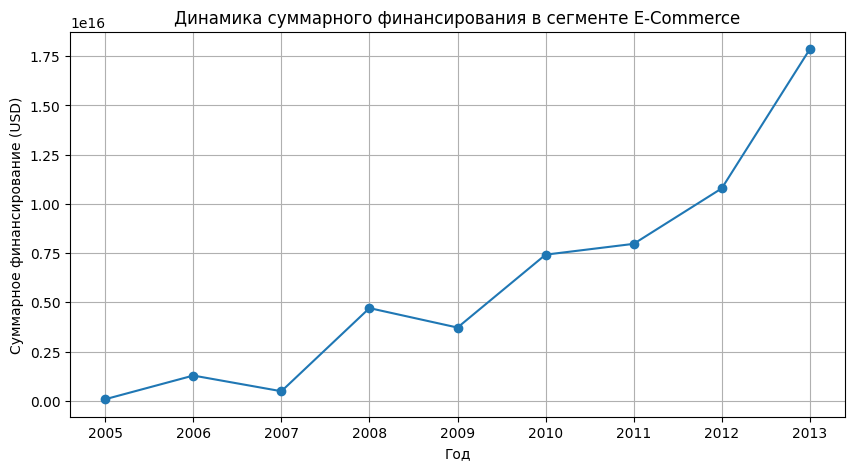

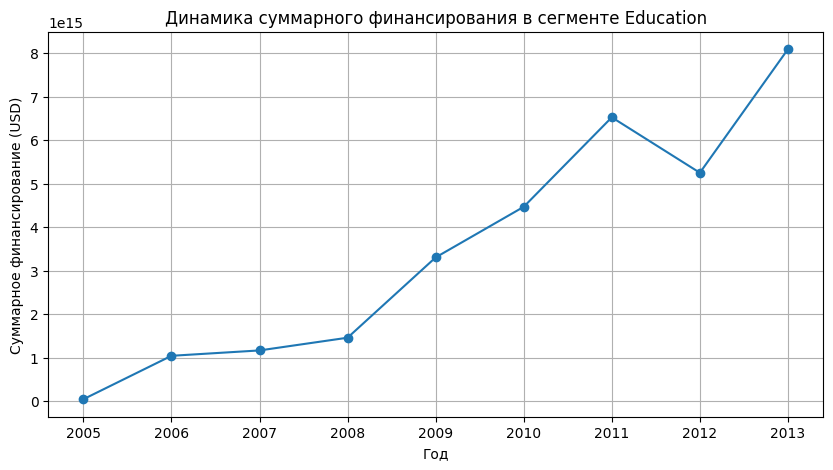

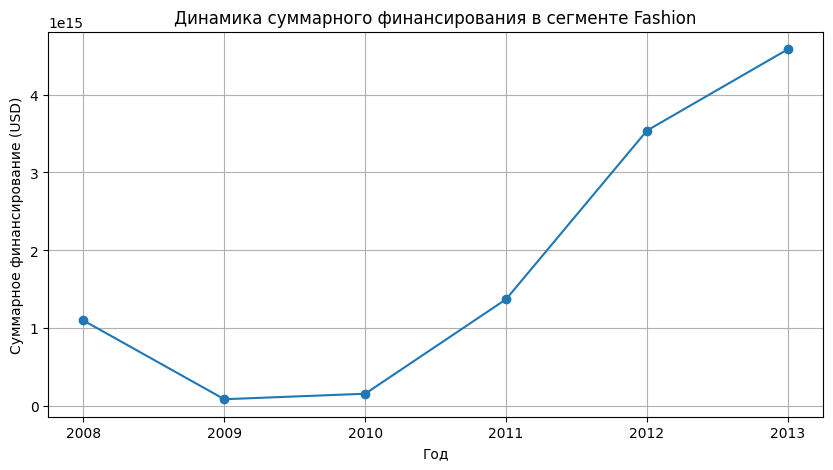

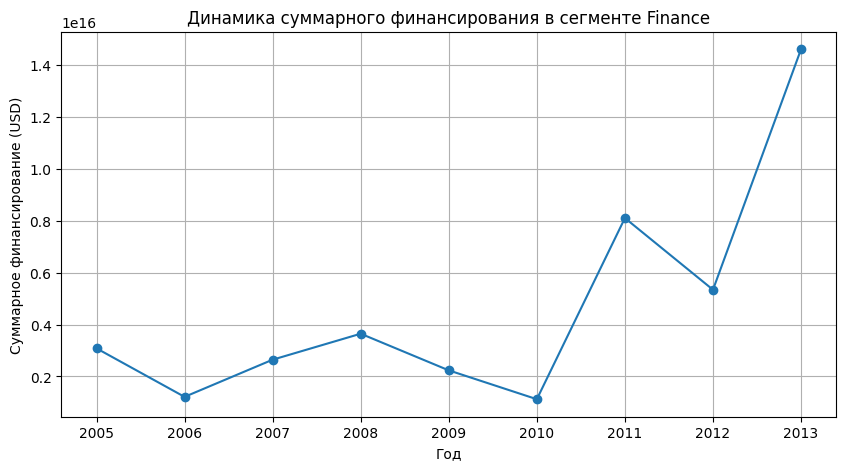

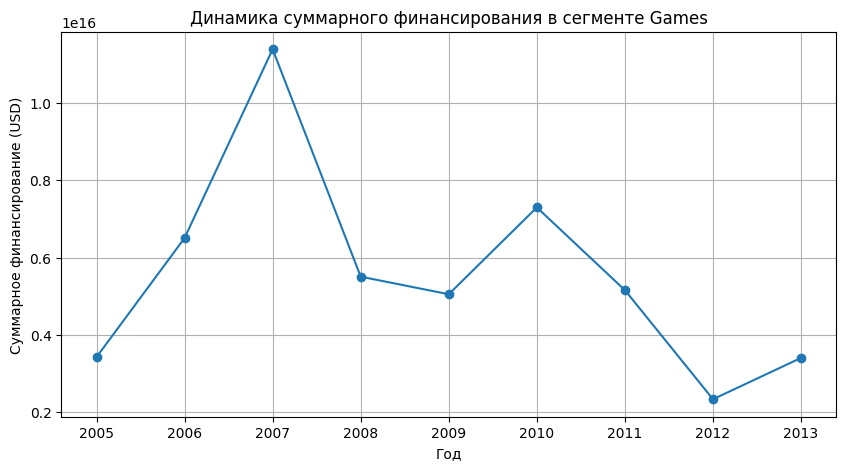

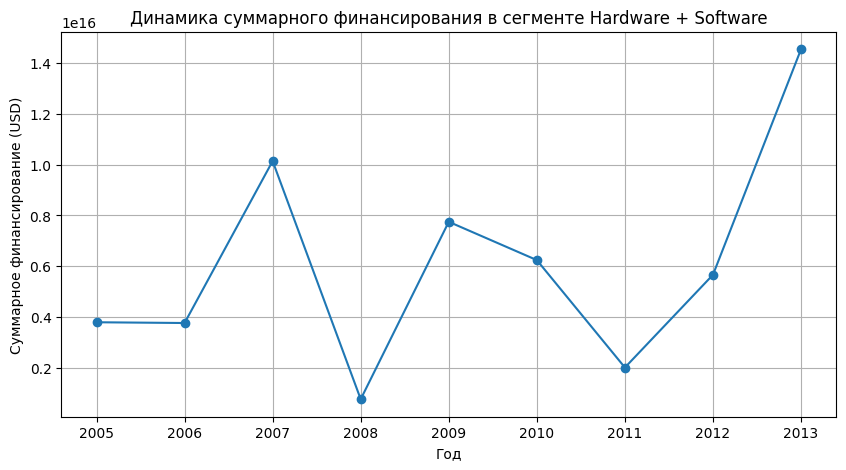

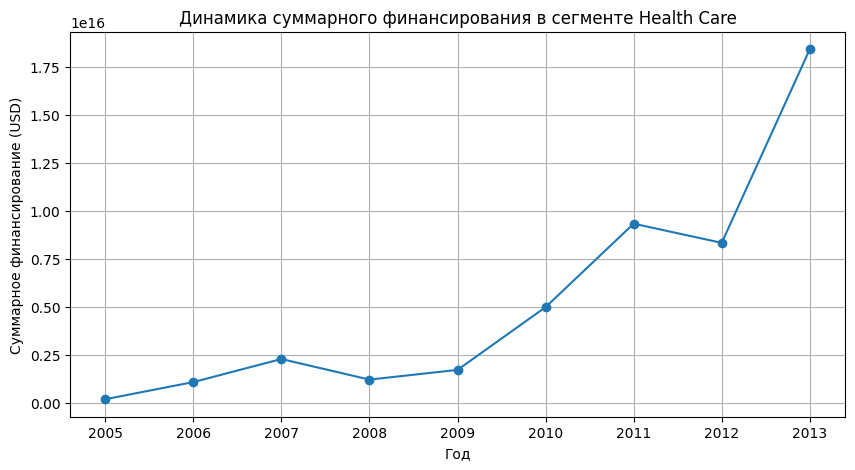

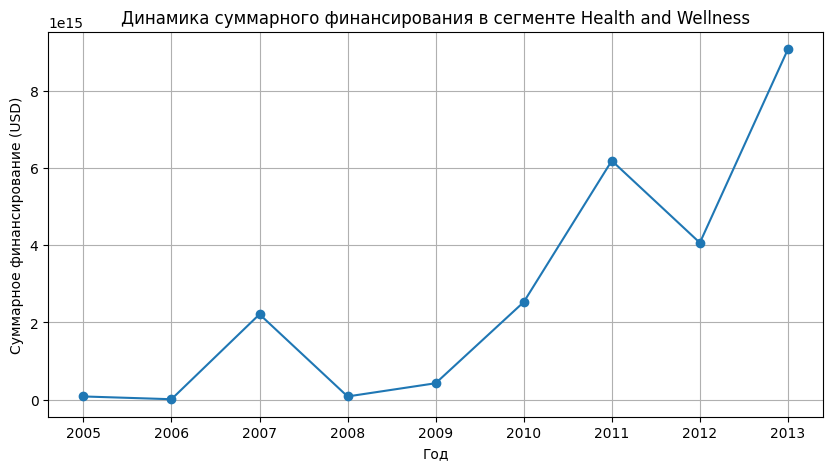

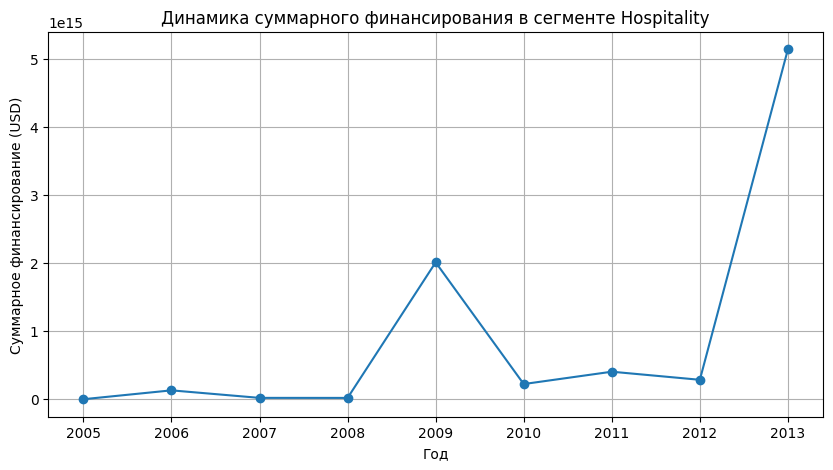

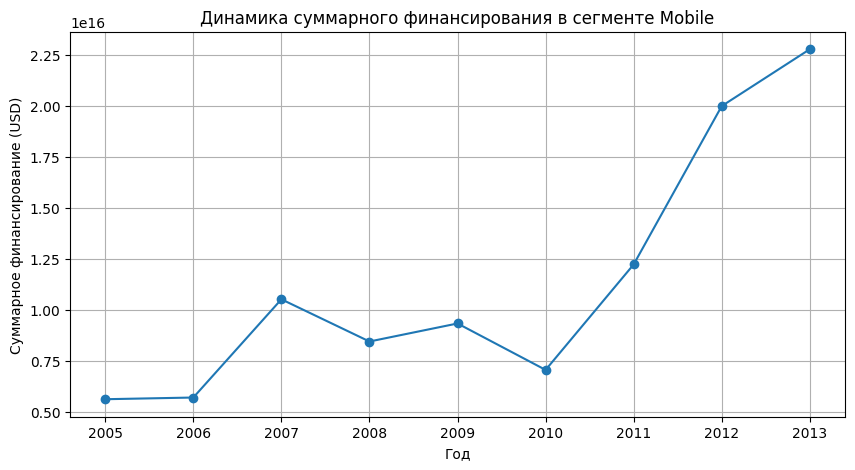

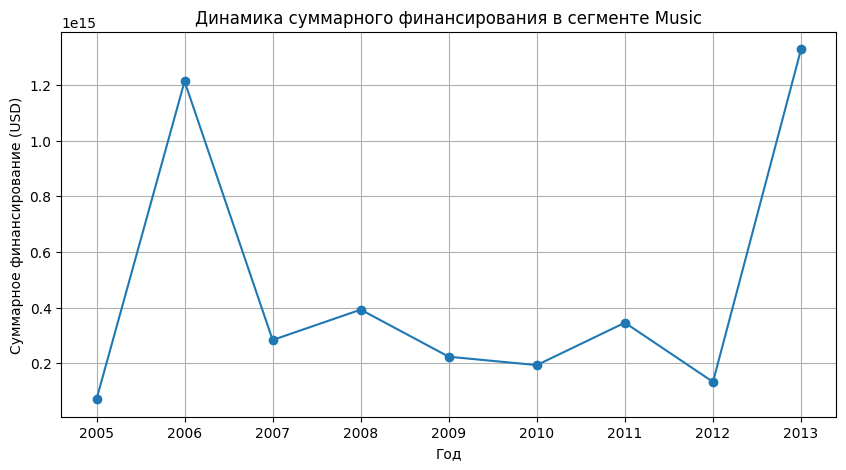

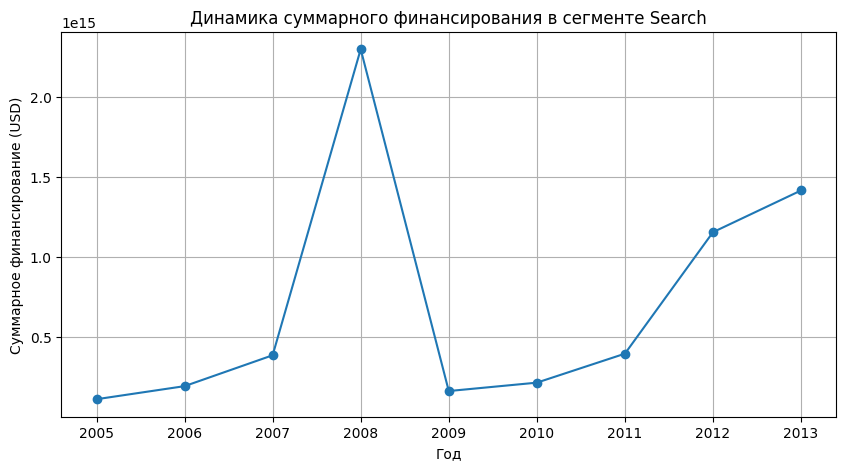

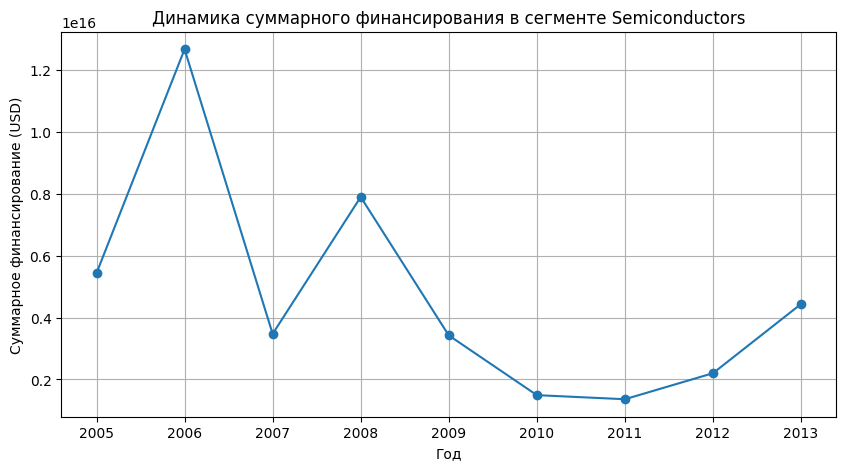

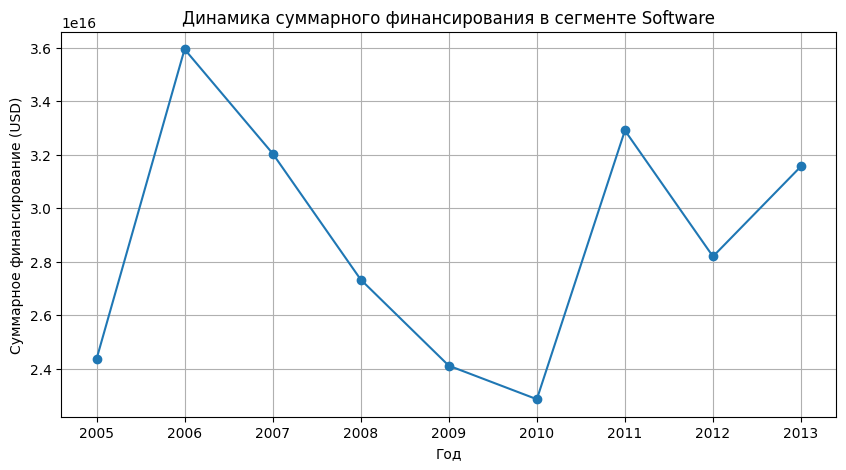

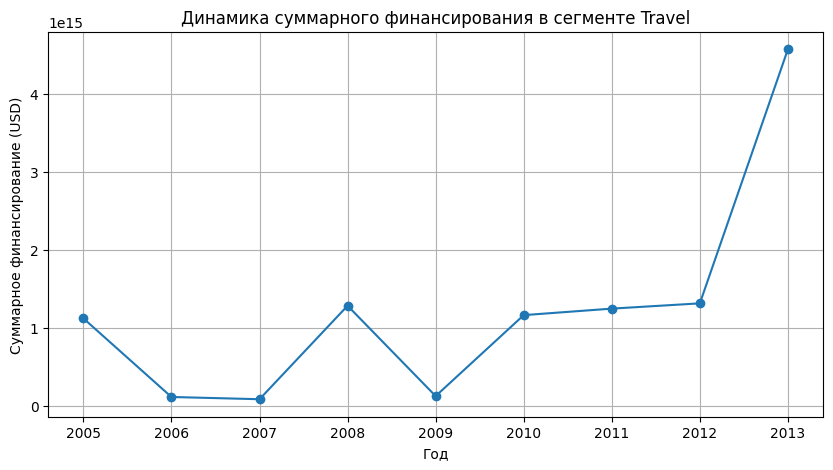

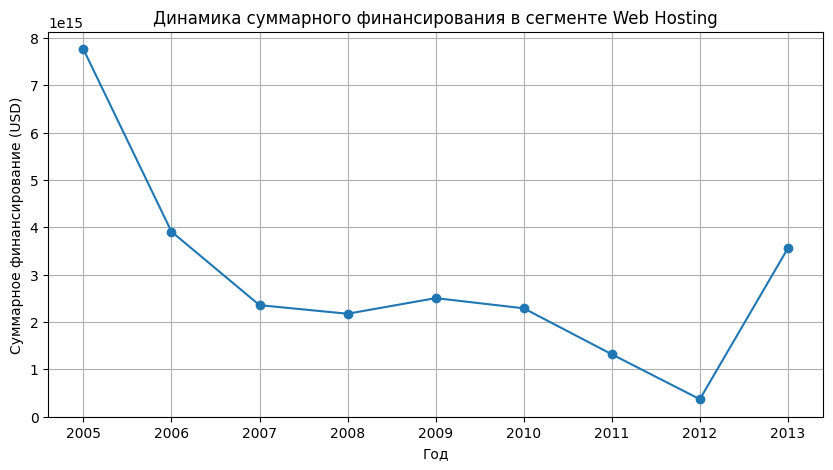

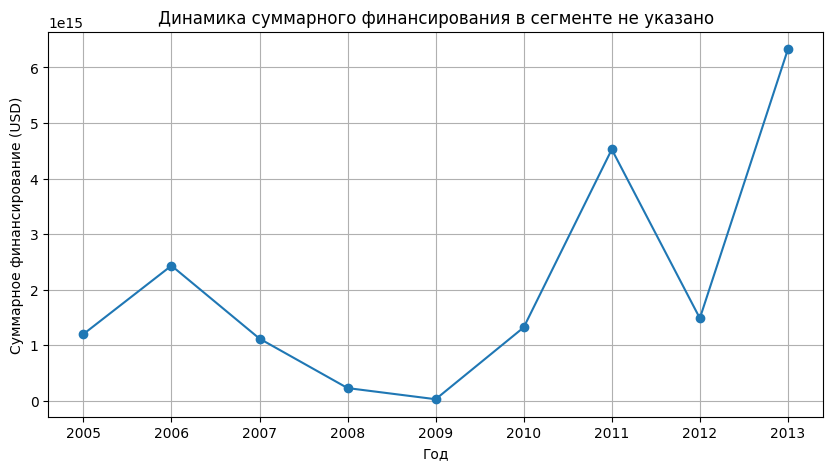

In [54]:
for segment in selected_segments:
    plt.figure(figsize=(10, 5))
    plt.plot(filtered_pivot_table.index, filtered_pivot_table[segment], marker='o')
    plt.title(f'Динамика суммарного финансирования в сегменте {segment}')
    plt.xlabel('Год')
    plt.ylabel('Суммарное финансирование (USD)')
    plt.grid()
    plt.show()

<div class="alert alert-block alert-info">
     На основе графика сделайте вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост:
    Уверенный рост показывают сегменты:
    <ol>
        <li>Analytics(c 2008 года)</li>
        <li>Biotechnology(c 2008 года)</li>
        <li>Consulting(с 2011 года)</li>
        <li>Education(с 2008 года)</li>
        <li>Health and Wellness(с 2008 года)</li>
        <li>Hospitality(с 2012 года)</li>
        <li>Travel(в период с 2012)</li>
    </ol>
    Наибольший рост в данном случае считаем как увеличение финансирования в несоклько раз(пример- финансирование сегмента Education с 2008 года вырос примерно в 8 раз). Подозрительно, что для сегмента Games снизилось финансирование при том, что появлялось больше технологий и студий разработки игр.
</div>

## 4.3 Годовая динамика доли возвращённых средств по типам финансирования
Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.<br>
Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например, 1e-60. Это поможет избежать деления на ноль.<br>
Постройте график, на котором отобразите нормированные значения возврата средств для типов финансирования venture, debt_financing, private_equity, seed и angel.<br>
Сделайте вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

In [61]:
# Извлечение года из столбца last_funding_at
cb_investments['year'] = pd.to_datetime(cb_investments['last_funding_at']).dt.year

# Группировка по годам и вычисление сумм для выбранных столбцов
grouped_investments = cb_investments.groupby('year')[['seed', 'venture', 'debt_financing', 'private_equity', 'angel']].sum()
grouped_investments = grouped_investments.reset_index()


cb_returns_parted = cb_returns[['venture', 'debt_financing', 'private_equity', 'seed','angel']]

cb_returns_parted = cb_returns_parted.reset_index()


merged_data = cb_returns_parted.merge(grouped_investments, on='year', how='left')


new_order = ['year', 
'venture_x', 
'venture_y',
'debt_financing_x', 
'debt_financing_y',
'private_equity_x',
'private_equity_y',
'seed_x',
'seed_y',
'angel_x',
'angel_y']
merged_data = merged_data[new_order]
merged_data

,year,venture_x,venture_y,debt_financing_x,debt_financing_y,private_equity_x,private_equity_y,seed_x,seed_y,angel_x,angel_y
0,2000,55400000.00000,NaN,8660000.00000,NaN,0.00000,NaN,16700000.00000,NaN,6430000.00000,NaN
1,2001,23490000.00000,NaN,4490000.00000,NaN,0.00000,NaN,2880000.00000,NaN,1180000.00000,NaN
2,2002,209420000.00000,NaN,3420000.00000,NaN,1510000.00000,NaN,6590000.00000,NaN,3410000.00000,NaN
3,2003,233860000.00000,NaN,1090000.00000,NaN,1620000.00000,NaN,7740000.00000,NaN,3410000.00000,NaN
4,2004,555900000.00000,NaN,13550000.00000,NaN,2190000.00000,NaN,9930000.00000,NaN,9180000.00000,NaN
5,2005,2628920000.00000,1842272911.00000,35090000.00000,907060.00000,2400000.00000,0.00000,26600000.00000,8278320.00000,31060000.00000,21103800.00000
6,2006,3100180000.00000,2122840763.00000,113210000.00000,12821772.00000,16670000.00000,2300000.00000,61810000.00000,15773820.00000,47750000.00000,17680000.00000
7,2007,3585370000.00000,2295328918.00000,125680000.00000,21135156.00000,88810000.00000,5000000.00000,70410000.00000,58338468.00000,164510000.00000,85630063.00000
8,2008,2717020000.00000,2319333846.00000,397540000.00000,25100000.00000,130380000.00000,0.00000,89720000.00000,123934184.00000,102830000.00000,140014858.00000
9,2009,2501290000.00000,2333634675.00000,394100000.00000,41821515.00000,203700000.00000,0.00000,160210000.00000,104743662.00000,97210000.00000,95643234.00000


In [62]:
# Расчёт нормированных значений
def calculate_normalized_return(provided, returned):
    return returned / (provided + 1e-60)


merged_data['normalized_venture'] = calculate_normalized_return(merged_data['venture_x'], merged_data['venture_y'])
merged_data['normalized_debt_financing'] = calculate_normalized_return(merged_data['debt_financing_x'], merged_data['debt_financing_y'])
merged_data['normalized_private_equity'] = calculate_normalized_return(merged_data['private_equity_x'], merged_data['private_equity_y'])
merged_data['normalized_seed'] = calculate_normalized_return(merged_data['seed_x'], merged_data['seed_y'])
merged_data['normalized_angel'] = calculate_normalized_return(merged_data['angel_x'], merged_data['angel_y'])

# Обработка аномальных значений
threshold = 10  # Примерное значение для замены аномальных значений
merged_data[['normalized_venture', 'normalized_debt_financing', 'normalized_private_equity', 'normalized_seed', 'normalized_angel']] = \
    merged_data[[ 'normalized_venture', 'normalized_debt_financing', 'normalized_private_equity', 'normalized_seed', 'normalized_angel']].apply(lambda x: x.mask(x > threshold, other=None))

# Представление данных в формате таблицы
result_table = merged_data[['year', 'normalized_venture', 
                             'normalized_debt_financing',
                            'normalized_private_equity',
                            'normalized_seed',
                            'normalized_angel']]
result_table

,year,normalized_venture,normalized_debt_financing,normalized_private_equity,normalized_seed,normalized_angel
0,2000,NaN,NaN,NaN,NaN,NaN
1,2001,NaN,NaN,NaN,NaN,NaN
2,2002,NaN,NaN,NaN,NaN,NaN
3,2003,NaN,NaN,NaN,NaN,NaN
4,2004,NaN,NaN,NaN,NaN,NaN
5,2005,0.70077,0.02585,0.00000,0.31122,0.67945
6,2006,0.68475,0.11326,0.13797,0.25520,0.37026
7,2007,0.64019,0.16817,0.05630,0.82855,0.52052
8,2008,0.85363,0.06314,0.00000,1.38134,1.36161
9,2009,0.93297,0.10612,0.00000,0.65379,0.98388


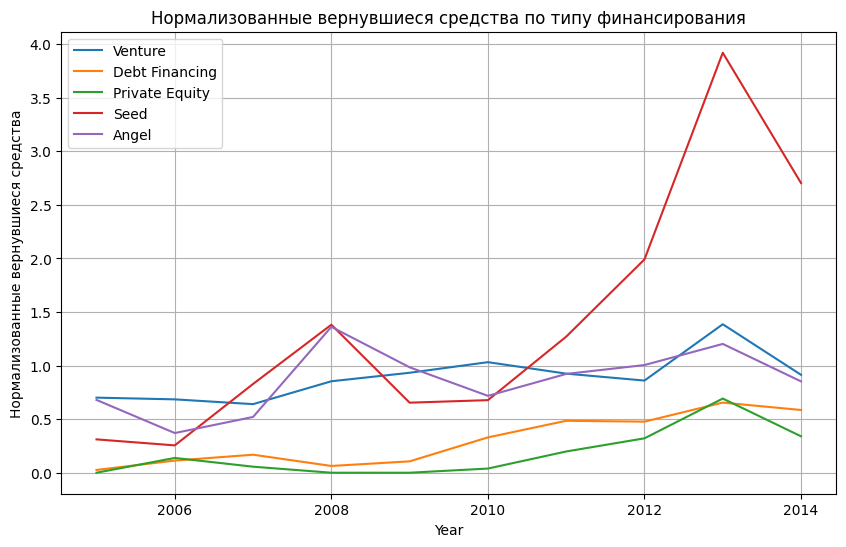

In [63]:
# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(merged_data['year'], merged_data['normalized_venture'], label='Venture')
plt.plot(merged_data['year'], merged_data['normalized_debt_financing'], label='Debt Financing')
plt.plot(merged_data['year'], merged_data['normalized_private_equity'], label='Private Equity')
plt.plot(merged_data['year'], merged_data['normalized_seed'], label='Seed')
plt.plot(merged_data['year'], merged_data['normalized_angel'], label='Angel')
plt.xlabel('Year')
plt.ylabel('Нормализованные вернувшиеся средства')
plt.title('Нормализованные вернувшиеся средства по типу финансирования')
plt.legend()
plt.grid()
plt.show()

По результатам анализа мы можем сравнивать данные с 2005 года, так как мы фильтровали данные по привлеченным средствам.
    Среди типов финансирования наблюдается наиболее устойчивый рост показателя возвращения средств по всем типам финансирования, кроме seed - для него наблюдается резкий скачок вернувшихся средств.


# Шаг 5. Итоговый вывод и рекомендации
Представьте, что на календаре 2015 год. Опираясь на результаты анализа, дайте рекомендацию заказчику:
1. в какую отрасль стоит инвестировать;
2. какой тип финансирования при этом будет наиболее уместным.<br>
Подведите итоги проекта:
* опишите, какие шаги были выполнены;
* какие выводы удалось сделать;
* насколько выводы согласуются между собой или, наоборот, вызывают сомнения.

<div class="alert alert-block alert-info">
<h2> Выводы<a class="tocSkip"></h2>
<ol>
    <li>в какую отрасль стоит инвестировать;</li>
    По результатам анализа имеет смысл инвестировать в следующие сегменты рынка: Биотехнологии, Консалтинг и Образование. По результатам анализа эти сегменты имеют большеи суммы вложений и хороший рост финансирования.
    <li>какой тип финансирования при этом будет наиболее уместным: уместно будет использовать венчурное или посевные инвестиции.</li></ol>

Подведите итоги проекта:
<ul>
<li>опишите, какие шаги были выполнены;
Была выполнена предобработка данных по приведению строковых типов к удобочитаемому виду, удалены столбцы, которые не несут информации для задачи,удалены строки, которые не момогали сделать выводы, удалены дубликаты.</li> 
<li>какие выводы удалось сделать;
Удалось посмотреть какие типы финансирования имеют наибольшую долю по сумме финансирования и количеству компаний - биотехнологии и разработка ПО.
Удалось посмотреть доли финансирования по различным сегментам рынка.
Удалось посмотреть динамику средств финансирования по годам и среднее количество раундов финансирования.
В сегментах также были выделены аномальные значения.
Выявлены группы компаний по сроку финансирования и суммы привлеченных ими средств.</li>
<li>насколько выводы согласуются между собой или, наоборот, вызывают сомнения - вызывают сомнения значительный процент аномальных инвестиций в нишевом и среднем сегменте рынка - откуда у некрупных компаний такие большие средства.
Тенденция на рост финансирования технологий выглядит правдоподобно, потому что в этот период возникло довольно много технологических компаний, которые затем получили финансирование.
При этом среди сегментов нишевый и средний(выделенных отдельных сегментов для учета маленьких сегментов по количеству компаний) существуют аномальные значения финансирования, вероятно это скошенность датасета и это могло быть финансирование редких, но дорогих стартапов.</li>
</ul>
</div>